# Exact-event Empirical-Bayes Screen

## 가설

기존 H0는 gene×functional event-type evidence를 암종별 26점수로 압축합니다. 이 실험은 fold-train에서 자동 생성한 모든 gene×normalized exact-event를 별도 Empirical-Bayes evidence로 압축해 allele/codon 수준 정보를 보존하는지 확인합니다.

## 규정·누수 계약

- train.csv만 읽고 test.csv를 읽지 않습니다.
- exact vocabulary, EB posterior, 표준화는 outer-fold train에서만 fit합니다.
- validation은 transform/evaluation만 수행합니다.
- 고정 암종·유전자·변이 목록, support cutoff, top-k, position-bin을 사용하지 않습니다.
- WT/빈 문자열/NaN은 event가 아니며 nan_as_mutation_count=0을 기록합니다.
- 기준 H0의 specialist/weight/margin은 바꾸지 않습니다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_015'
RUNNER = BASE / 'common' / 'run_exact_event_eb_screen.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-exact-event-eb-01'
SEED = 42
RUN_EXPERIMENT = True
assert RUNNER.exists()
print({'runner': RUNNER, 'seed': SEED, 'test_read': False, 'new_exact_event_rule': 'fold_train_auto_vocabulary'})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_015/common/run_exact_event_eb_screen.py'), 'seed': 42, 'test_read': False, 'new_exact_event_rule': 'fold_train_auto_vocabulary'}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seed', str(SEED)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='exact-event EB screen', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('exact-event EB screen failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: existing result files only.')

exact-event EB screen: 1line [00:05,  5.19s/line]

[exact-event EB] seed 42, fold 1/5


exact-event EB screen: 2line [05:56, 208.75s/line]

[exact-event EB] seed 42, fold 2/5


exact-event EB screen: 3line [11:57, 278.39s/line]

...

exact-event EB screen: 5line [23:59, 329.25s/line]

[exact-event EB] seed 42, fold 5/5


exact-event EB screen: 6line [30:04, 341.38s/line]

{"run_id": "exp-exact-event-eb-01", "seed": 42, "screen_delta_required": 0.015, "delta_vs_h0": 0.022238963928857602, "positive_fold_count": 5, "screen_pass": true, "test_read": false, "train_test_concat": false, "fixed_class_gene_exact_mutation_rules": false, "exact_support_cutoff": null, "leakage_check": true, "nan_as_mutation_count": 0}


exact-event EB screen: 6line [30:05, 300.84s/line]


,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,42,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,1798.667089,0.000000
1,42,exact_event_EB,0.570154,0.584906,8245.2,0,True,0,1798.689360,0.022239


variant,H0_selective_EB,exact_event_EB
fold,,
1,0.528516,0.560260
2,0.551891,0.567198
3,0.543449,0.560603
4,0.554759,0.565532
5,0.558499,0.595970


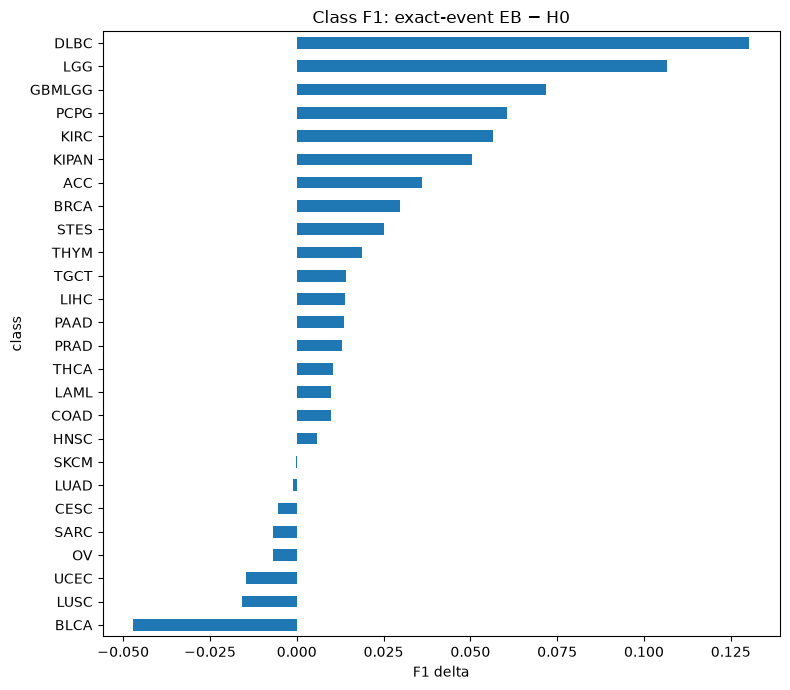

{'screen_pass': True, 'delta_vs_h0': 0.022238963928857602, 'positive_fold_count': 5, 'next': '3-seed only if screen_pass else stop this axis'}


In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed{SEED}_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
assert audit['leakage_check'] and not audit['test_read'] and audit['exact_support_cutoff'] is None
display(summary)
display(folds.pivot(index='fold', columns='variant', values='macro_f1'))

class_f1 = classes.pivot(index='class', columns='variant', values='f1')
(class_f1['exact_event_EB'] - class_f1['H0_selective_EB']).sort_values().plot.barh(figsize=(8, 7), title='Class F1: exact-event EB − H0')
plt.xlabel('F1 delta'); plt.tight_layout(); plt.show()

print({'screen_pass': audit['screen_pass'], 'delta_vs_h0': audit['delta_vs_h0'], 'positive_fold_count': audit['positive_fold_count'], 'next': '3-seed only if screen_pass else stop this axis'})